# 3장 1강: 편향-분산 트레이드오프와 과적합/과소적합 진단

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 모델 복잡도와 과적합/과소적합의 관계를 확인합니다.

- 모델이 너무 단순할 때 나타나는 **고편향(과소적합)** 상태를 확인합니다.
- 모델이 너무 복잡할 때 나타나는 **고분산(과적합)** 상태를 확인합니다.
- `learning_curve()`를 이용하여 학습곡선을 확인합니다.
- `validation_curve()`를 이용하여 모델 복잡도에 따른 Train / Validation 성능 변화를 확인합니다.
- `train-valid gap`을 이용하여 모델 상태를 진단합니다.
- 진단 결과에 맞는 대응 전략을 선택합니다.

> 이 실습에서는 3장 1강 교안에서 다룬 편향-분산, 학습곡선, 검증곡선, train-valid gap, 과적합/과소적합 대응 전략만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- numpy
- matplotlib
- scikit-learn
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 여러 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

이번 강의의 목적은 예측 성능 자체를 최대화하는 것이 아니라 **모델 복잡도에 따라 Train / Validation 성능이 어떻게 달라지는지 진단하는 것**입니다.

### 사용할 특성

결측치 처리 자체가 이번 강의의 학습 목표가 아니므로, 결측치가 없는 숫자형 특성 중 일부만 사용합니다.

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `TotalBsmtSF`
- `1stFlrSF`
- `YearBuilt`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 특성과 예측 대상을 선택합니다.
3. 결측치가 없는지 확인합니다.
4. 데이터 크기와 기초 통계량을 확인합니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve, validation_curve

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt"
]

X = house[features]
y = house["SalePrice"]

print("X 크기:", X.shape)
print("y 크기:", y.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

print("\n[기초 통계량]")
display(X.describe())

X 크기: (1460, 6)
y 크기: (1460,)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
1stFlrSF,0
YearBuilt,0



[기초 통계량]


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1162.626712,1971.267808
std,1.382997,525.480383,0.747315,438.705324,386.587738,30.202904
min,1.000000,334.000000,0.000000,0.000000,334.000000,1872.000000
25%,5.000000,1129.500000,1.000000,795.750000,882.000000,1954.000000
50%,6.000000,1464.000000,2.000000,991.500000,1087.000000,1973.000000
75%,7.000000,1776.750000,2.000000,1298.250000,1391.250000,2000.000000
max,10.000000,5642.000000,4.000000,6110.000000,4692.000000,2010.000000


---

# 필수 1. 학습곡선으로 과소적합과 과적합 진단

## 배경

학습곡선은 **학습 데이터의 양을 늘려가며 Train score와 Validation score가 어떻게 변하는지 확인하는 그래프**입니다.

이번 문제에서는 같은 Ames Housing 데이터에 대해 두 개의 결정트리를 비교합니다.

- `max_depth=2` → 복잡도가 낮은 모델
- `max_depth=None` → 깊이를 제한하지 않은 복잡한 모델

## 문제 1. `max_depth=2` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=2, random_state=42)`를 만듭니다.
2. `learning_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 학습 데이터 비율은 `np.linspace(0.1, 1.0, 6)`을 사용합니다.
5. 각 구간의 Train score와 Validation score 평균을 계산합니다.
6. 두 점수를 하나의 그래프에 표시합니다.
7. 두 곡선이 어디에서 수렴하는지 확인합니다.

### 확인 포인트

- 두 점수가 모두 낮은 수준에서 가까워지는가?
- 모델이 너무 단순한 상태인지 판단할 수 있는가?

,train_r2,valid_r2,gap
0,0.7018,0.5778,0.1240
1,0.6697,0.6005,0.0692
2,0.6646,0.5940,0.0706
3,0.6533,0.6005,0.0528
4,0.6455,0.5744,0.0712
5,0.6341,0.6024,0.0317


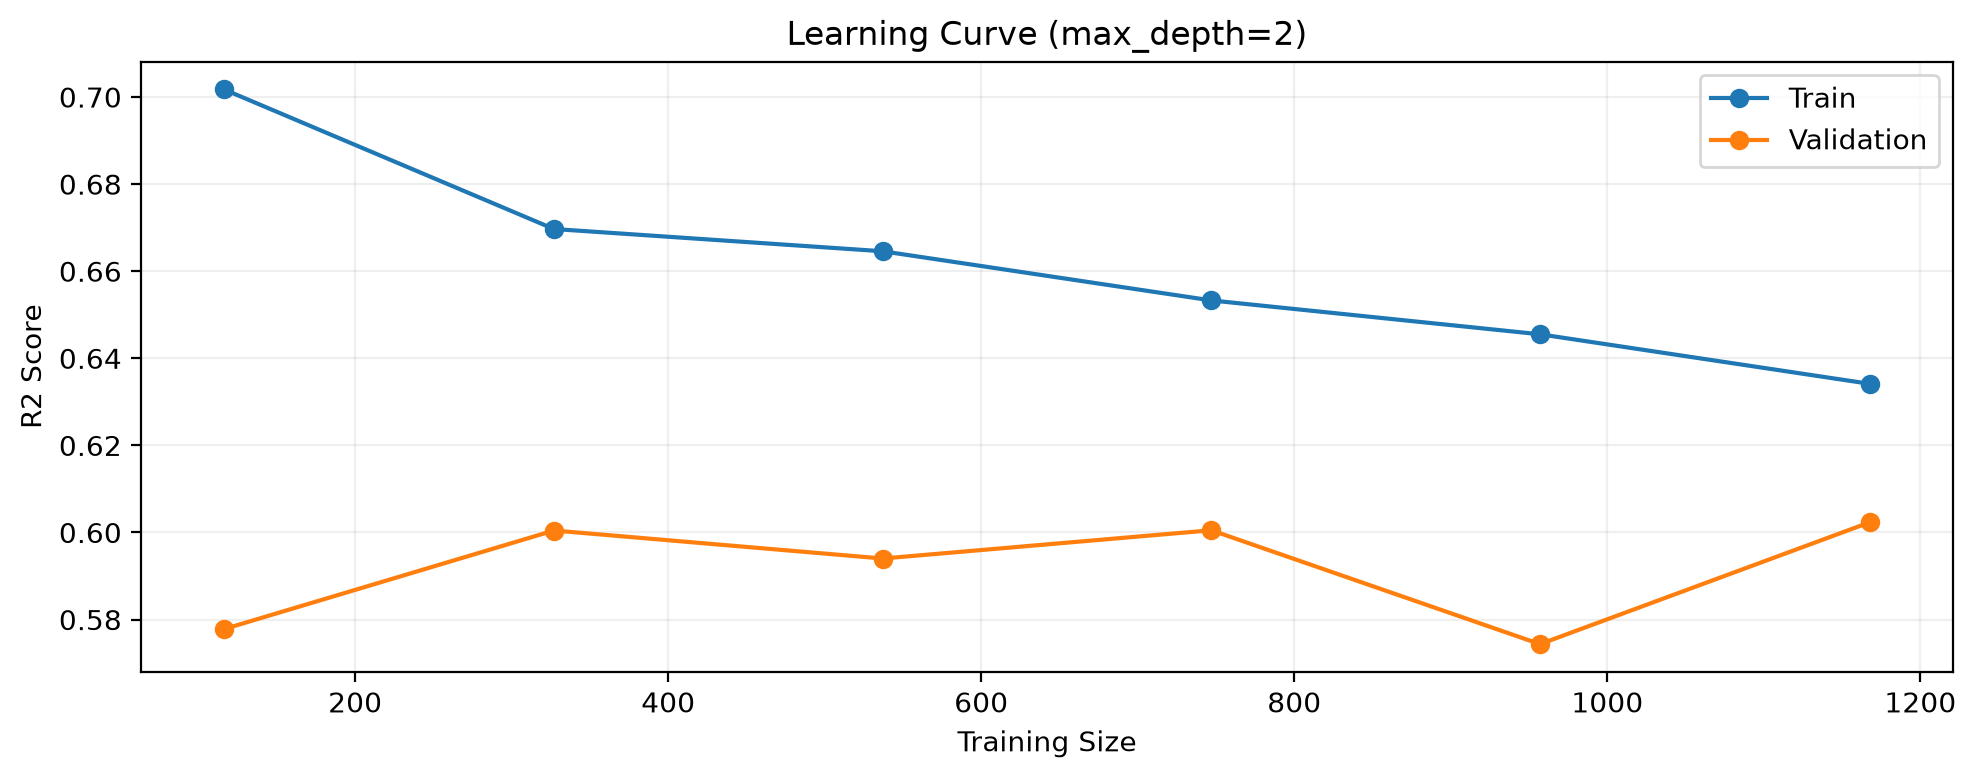

In [2]:
# TODO
# max_depth=2 결정트리의 학습곡선을 그려보세요.


# 1. 결정트리 모델 생성
dt_model = DecisionTreeRegressor(max_depth=2, random_state=42)

# 2. 학습곡선 계산
train_sizes, train_scores, valid_scores = learning_curve(
                                            dt_model, X, y,
                                            train_sizes=np.linspace(0.1, 1.0, 6),
                                            cv=5,
                                            scoring="r2"
)

# 3. 평균 점수 계산
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)


# 4. 결과 DataFrame
result = pd.DataFrame({
    "train_r2": train_mean,
    "valid_r2": valid_mean,
    "gap": train_mean - valid_mean
})

display(result.round(4))


# 4. 학습곡선 시각화
plt.figure(figsize=(10, 4))

plt.plot(train_sizes, train_mean,  marker="o",  label="Train")

plt.plot(train_sizes, valid_mean, marker="o", label="Validation")

plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve (max_depth=2)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

- R2(결정계수) : 
    - R2 = 1 (실제값과 예측값이 일치)
    - R2 = 0 (실제 평균만 예측, 충분히 설명하지 못함)

|학습샘플수|해석|판단|
|---|---|---|
|116|Train R2의 평균(`0.70`) / Validation R2의 평균(`0.57`)|적은 학습데이터에서 비교적 차이가 큼(`0.13`)|
|327|Train R2의 평균(`0.66`) / Validation R2의 평균(`0.60`)|Train 데이터의 R2은 `0.04` 감소 / Validation의 R2은 `0.03` 상승 <br> (격차가 줄어들었다)|
|537|Train R2의 평균(`0.66`) / Validation R2의 평균(`0.59`)|Train R2은 유지 / Validation R2은 0.01 감소|
|1,168|Train R2의 평균(`0.63`) / Validation R2의 평균(`0.60`)|평균점수 차이가 가장 낮다|

<br>

> **해석:**   
> 깊이 2의 결정트리는 최대 Fold의 학습크기 1,168개에서 Train R2가 0.63, Validation R2가 0.60으로 나타난다.   
> 두 점수의 차이는 1,168에서 격차가 가장 작았지만 R2이 낮아 과소적합을 의심해야한다.

---

### Q1. `max_depth=2` 모델은 과소적합과 과적합 중 어느 쪽에 더 가깝다고 볼 수 있나요?

**답변:**  
- 과소적합. Train과 Validation의 R2값이 모두 낮았으며 그 간격도 작았다.
- R2 값이 Train과 Validation에서 약 0.60정도, 즉 데이터에 대한 파악이 약 60점 정도라고 보인다.
- R2 값이 비교적 0.60으로 낮기 때문에 모델이 해당 데이터에 대한 충분한 파악을 하지 못한 과소적합을 의심해 볼 수 있다.
- 단, R2가 0.60이면 무조건 낮다. -> 이 기준이 없기 때문에 추후 다른 평가지표나 그래프를 통해 근거를 강화해야한다.


## 문제 2. `max_depth=None` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=None, random_state=42)`를 만듭니다.
2. 필수 1 문제 1과 동일한 방식으로 `learning_curve()`를 사용합니다.
3. Train score와 Validation score를 그래프로 나타냅니다.
4. 두 곡선 사이의 간격을 확인합니다.

### 확인 포인트

- Train score가 매우 높은가?
- Validation score와의 간격이 크게 유지되는가?
- 고분산(과적합) 신호를 확인할 수 있는가?

,train_r2,valid_r2,gap
0,0.9999,0.5898,0.4101
1,1.0000,0.7043,0.2956
2,0.9999,0.7153,0.2846
3,0.9998,0.6693,0.3306
4,0.9998,0.6849,0.3149
5,0.9998,0.7272,0.2726


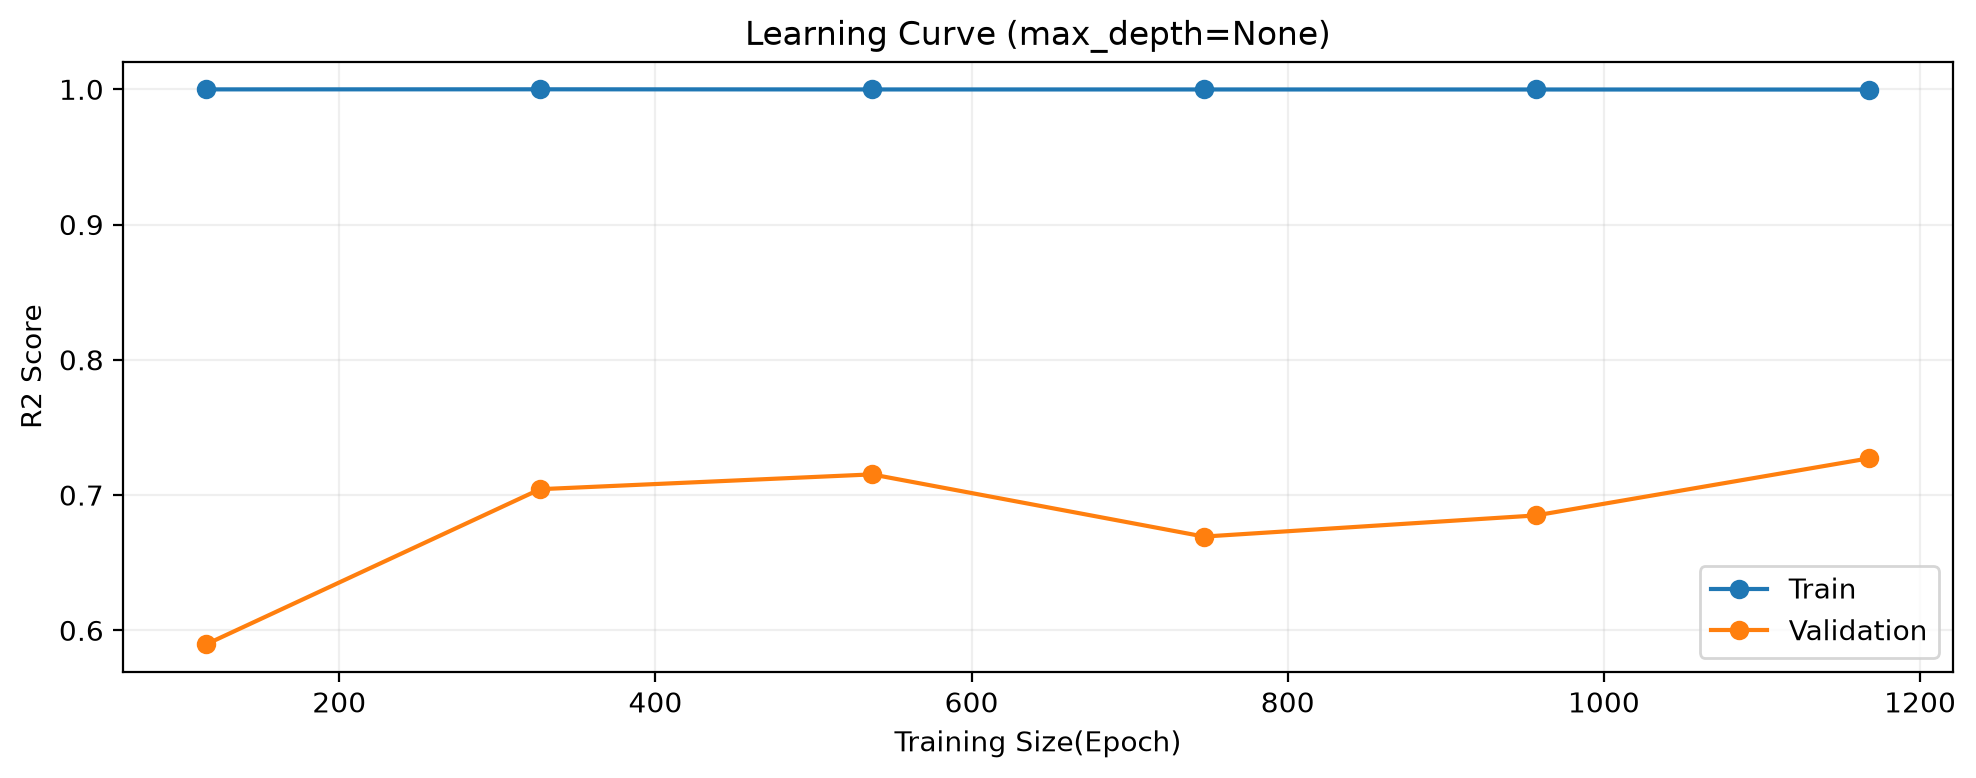

In [3]:
# TODO
# max_depth=None 결정트리의 학습곡선을 그려보세요.

# 1. 결정트리 모델 생성
dt_model = DecisionTreeRegressor(max_depth=None, random_state=42)

# 2. 학습곡선 계산
train_sizes, train_scores, valid_scores = learning_curve(
                                            dt_model, X, y,
                                            train_sizes=np.linspace(0.1, 1.0, 6),
                                            cv=5,
                                            scoring="r2"
)

# 3. 평균 점수 계산
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)


# 5. 결과 DataFrame
result = pd.DataFrame({
    "train_r2": train_mean,
    "valid_r2": valid_mean,
    "gap": train_mean - valid_mean
})

display(result.round(4))


# 4. 학습곡선 시각화
plt.figure(figsize=(10, 4))

plt.plot(train_sizes, train_mean,  marker="o",  label="Train")

plt.plot(train_sizes, valid_mean, marker="o", label="Validation")

plt.xlabel("Training Size(Epoch)")
plt.ylabel("R2 Score")
plt.title("Learning Curve (max_depth=None)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

|학습샘플수|해석|판단|
|---|---|---|
|116|Train R2의 평균(`0.99`) / Validation R2의 평균(`0.59`)|점수 차이(`0.40`)|
|327|Train R2의 평균(`1.00`) / Validation R2의 평균(`0.70`)|점수 차이(`0.29`)|
|537|Train R2의 평균(`0.99`) / Validation R2의 평균(`0.71`)|점수 차이(`0.28`)|
|1,168|Train R2의 평균(`0.99`) / Validation R2의 평균(`0.72`)|점수 차이(`0.27`) <br> - 해당 학습 샘플 수를 선택하여 모델링하는 것이 유리|

- Train R2의 평균 0.99의 의미 : 매우 작은 제곱오차로 맞추고 있다. (극소한 차이까지 맞춤)
- Train R2과 Validation R2의 차이가 0.27의 의미 : 
    - R2의 차이가 0.27이라고 해서 27%만큼 Validation이 더 틀렸다고 해석하면 X
    - Train의 점수는 0.99점이고 Validation의 점수는 0.27로 차이가 크다는 것은 과적합의 신호


> **해석:**   
> 깊이 제한이 없는 트리 모델의 경우 Train R2이 거의 1에 가까움,   
> 다만 Validation R2은 0.59 ~ 0.72까지 다양함.   
> 학습량 증가에 따른 Validation의 개선의 여지가 보이지만 Train R2과 Validation R2의 격차를 줄이지 못해   
> 과적합 가능성을 보고 다른 평가지표와 그래프 등을 확인해 보아야한다.



### Q2. `max_depth=None` 모델에서 데이터를 더 추가하는 것이 도움이 될 가능성이 있는 이유는 무엇인가요?

**답변:**  
- 과적합 상태에서는 모델이 현재 데이터를 지나치게 학습을 한 상태로,
- 학습 데이터가 더 많아지면 현재 학습했던 패턴 외에 패턴들을 학습할 수가 있기 때문에
- Train과 Validation의 격차가 줄어들 수 있다.

---

# 필수 2. 검증곡선과 train-valid gap으로 최적 복잡도 확인

## 배경

검증곡선은 **모델의 하이퍼파라미터를 바꿔가며 Train score와 Validation score의 변화를 확인하는 그래프**입니다.

이번 문제에서는 결정트리의 `max_depth`를 바꾸어 모델 복잡도를 조절합니다.

## 문제 1. `max_depth` 검증곡선을 만드세요.

### 요구사항

1. 다음 `max_depth` 후보를 사용합니다.

```python
param_range = [1, 2, 3, 4, 5, 8, 12, 20, None]
```

2. `validation_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 각 `max_depth`의 Train score와 Validation score 평균을 계산합니다.
5. `gap = train_mean - valid_mean`을 계산합니다.
6. `max_depth`, `train`, `validation`, `gap`을 DataFrame으로 만듭니다.
7. Train / Validation score를 하나의 그래프에 표시합니다.

### 확인 포인트

- 복잡도가 증가할수록 Train score가 어떻게 변하는가?
- Validation score는 어느 지점까지 좋아지고 이후 어떻게 변하는가?
- train-valid gap은 깊이가 커질수록 어떻게 변하는가?

,max_depth,train_r2,valid_r2,gap
0,1.0,0.4545,0.4298,0.0247
1,2.0,0.6341,0.6024,0.0317
2,3.0,0.7336,0.6791,0.0545
3,4.0,0.8115,0.7335,0.0780
4,5.0,0.8624,0.7556,0.1068
5,8.0,0.9482,0.7709,0.1773
6,12.0,0.9898,0.7461,0.2437
7,20.0,0.9997,0.7353,0.2644
8,NaN,0.9998,0.7272,0.2726


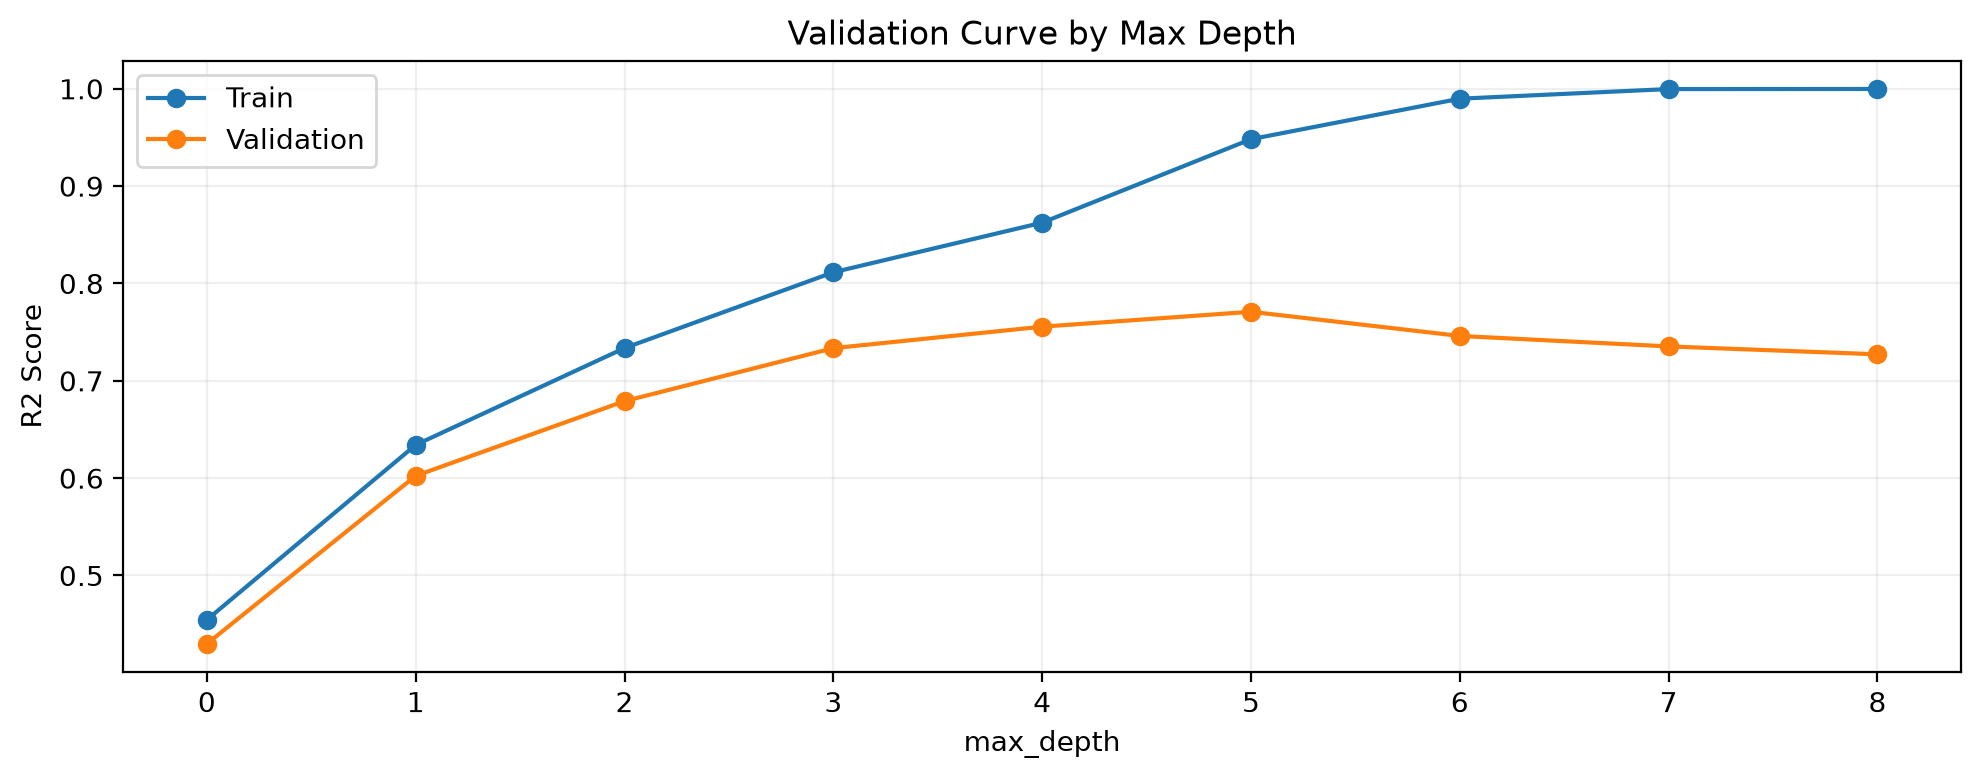

In [4]:
# TODO
# validation_curve()를 이용해 max_depth별 Train / Validation score와 gap을 확인하세요.

# 1. max_depth 범위
depth_range = [1, 2, 3, 4, 5, 8, 12, 20, None]

# 2. 결정트리 모델
dt_model = DecisionTreeRegressor(random_state=42)

# 3. Validation Curve
train_scores, valid_scores = validation_curve(
    dt_model,
    X,
    y,
    param_name="max_depth",
    param_range=depth_range,
    cv=5,
    scoring="r2"
)

# 4. 평균 점수 계산
train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

# 5. 결과 DataFrame
result = pd.DataFrame({
    "max_depth": depth_range,
    "train_r2": train_mean,
    "valid_r2": valid_mean,
    "gap": train_mean - valid_mean
})

display(result.round(4))

# 6. Validation Curve 시각화
plt.figure(figsize=(10, 4))

plt.plot(
    range(len(depth_range)),
    result["train_r2"],
    marker="o",
    label="Train"
)

plt.plot(
    range(len(depth_range)),
    result["valid_r2"],
    marker="o",
    label="Validation"
)


plt.xlabel("max_depth")
plt.ylabel("R2 Score")
plt.title("Validation Curve by Max Depth")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

- 학습곡선과 검증곡선의 목적 구분
    - 학습 곡선: 학습자료의 수를 바꾸고 / 검증곡선: max_depth를 바꾼다.
    - 모델결과를 유지하여는 핵심 조건은 학습곡선은 트리 깊이 설정, 검증곡선은 데이터와 교차검증 분할
    - **학습곡선의 메인 질문 : 데이터가 늘어나면 늘어날수록 성능이 어떻게 달라지는가?**
    - **검증곡선의 메인질문 : 오차나 변동이 큰 경우 성능이 어떻게 달라지는가?**

| max_depth | Train R² 평균 | Validation R² 평균 | Gap | 진단 근거 |
| :---: | ---: | ---: | ---: | --- |
| 1 | 0.4545 | 0.4298 | 0.0247 | 두 점수 모두 상대적으로 낮음 |
| 2 | 0.6341 | 0.6024 | 0.0317 | 깊이 1보다 개선되지만 표현력 제한 |
| 3 | 0.7336 | 0.6791 | 0.0545 | 학습, 검증 점수가 함께 상승 |
| 4 | 0.8115 | 0.7335 | 0.0780 | 검증 점수가 더 높아짐 |
| 5 | 0.8624 | 0.7556 | 0.1068 | 성능과 복잡도 균형을 검토할 수 있는 후보 |
| **8** | **0.9482** | **0.7709** | **0.1773** | **현재 9개 후보 중 검증 평균 최고** |
| 12 | 0.9898 | 0.7461 | 0.2437 | 학습은 개선되나 검증은 하락 |
| 20 | 0.9997 | 0.7353 | 0.2644 | 큰 일반화 차이가 남음 |
| None | 0.9998 | 0.7272 | 0.2726 | 거의 완벽한 학습점수와 큰 Gap |

<br>

> **해석 :**   
> 복잡도를 높이면 Train R2은 계속 상승하지만, Validation R2은 깊이 8에서 0.77로 가장 높고, 그 이후에 감소   
> 깊이 1같은 경우 R2값이 Train과 Test에서 모두 낮아 과소적합을 의심해볼 수 있으며    
> 매우 깊은 depth에서는 Train R2만 좋아져 과적합의 신호를 볼 수 있다.   
> 우선 가장 효과가 좋았던 depth8을 검토해볼 수 있다.
 
---

### Q3. Validation score가 가장 높은 `max_depth`는 무엇인가요?

**답변:**  
- 8


### Q4. `max_depth`가 매우 커질수록 train-valid gap이 커지는 이유는 무엇인가요?

**답변:**  

- `max_depth`는 트리의 깊이를 정하는 하이퍼파라미터로, max_depth가 커질수록 학습 데이터에 적합되기 때문
- 결정트리가 깊어질 수록 학습 데이터의 세부적인 패턴과 노이브까지 학습을 하려고 하기 때문에
- Train은 지속적으로 높아지지만 새로운 validate는 충분히 적응하지 못하기 때문에 유지되거나 낮아질 수 있다.

---

# 과제 1. 모델 상태를 진단하고 대응 전략 선택하기

## 배경

필수 실습에서는 학습곡선과 검증곡선을 이용해 모델의 상태를 확인했습니다.

이번 과제에서는 검증곡선 결과를 이용하여 세 가지 복잡도의 모델 상태를 직접 판단합니다.

> 과제는 필수 실습에서 확인한 결과를 해석하는 수준입니다.

## 문제

다음 세 모델을 확인하세요.

- `max_depth=1`
- `max_depth=8`
- `max_depth=None`

### 요구사항

1. 필수 2에서 만든 `gap_df`에서 세 모델의 Train score, Validation score, gap을 확인합니다.
2. 각 모델을 다음 중 하나로 진단합니다.
   - 과소적합
   - 비교적 적절한 복잡도
   - 과적합
3. 각 모델의 진단 근거를 Train score, Validation score, gap을 이용해 설명합니다.
4. 과소적합 또는 과적합 모델에 대해 교안에서 배운 대응 전략 중 적절한 방향을 하나 이상 작성합니다.

### 확인 포인트

- 점수가 낮고 gap이 작은 경우를 과소적합으로 해석할 수 있는가?
- Train score만 매우 높고 gap이 큰 경우를 과적합으로 해석할 수 있는가?
- Validation score가 높고 gap이 지나치게 크지 않은 지점을 적절한 후보로 볼 수 있는가?
- 진단 후에 대응 전략을 선택했는가?

In [5]:
# TODO
# gap_df에서 max_depth=1, 8, None에 해당하는 결과를 확인하세요.

gap_df = result.copy()
gap_df = result[(result["max_depth"].isin([1, 8])) | (result["max_depth"].isna())].round(4)

gap_df

,max_depth,train_r2,valid_r2,gap
0,1.0,0.4545,0.4298,0.0247
5,8.0,0.9482,0.7709,0.1773
8,NaN,0.9998,0.7272,0.2726


### Q5. 세 모델의 상태를 각각 진단하세요.

| max_depth | 진단 | 근거 |
|---|---|---|
| 1 | 과소적합 |  Train R²(0.4545)와 Valid R²(0.4298)가 모두 낮아 충분히 학습하지 못했을 가능성이 존재한다.|
| 8 | 과적합 | Train R²(0.9482)에 비해 Valid R²(0.7708)가 낮고 Gap이 크게 나타난다.|
| None | 과적합 | Train R²(0.9998)에 비해 Valid R²(0.7272)가 낮고 Gap(0.2726)이 가장 크게 나타난다. |

### Q6. 과소적합 모델과 과적합 모델에 각각 어떤 대응 전략을 사용할 수 있나요?

**답변:**  
- **과소적합:** max_depth를 증가시켜 모델의 복잡도를 높이고 데이터의 패턴을 충분히 학습한다.

- **과적합:** max_depth를 줄이거나 min_samples_leaf를 증가, 규제 증가를 통해 모델의 복잡도를 낮추고 일반화 성능을 개선시킨다.

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 편향이 높은 모델은 일반적으로 과소적합과 과적합 중 어느 상태와 관련이 있나요?
    - 편향이 높은 모델은 일반적으로 과소적합과 관련이 있다.

2. 분산이 높은 모델은 일반적으로 어느 상태와 관련이 있나요?
    - 과적합과 관련이 있다.

3. 학습곡선에서 Train과 Validation이 낮은 값에서 함께 수렴하면 어떤 상태인가요?
    - 과소적합의 신호

4. Train score는 매우 높지만 Validation score가 낮고 gap이 크다면 어떤 상태인가요?
    - 과적합의 신호

5. 검증곡선에서 Validation score가 가장 높은 지점은 어떤 의미를 가지나요?
    - 현재 후보 중에서 새로운 데이터에 대한 성능이 가장 좋은, 적절한 모델후보로 선택할 수 있다.

6. 과적합과 과소적합을 진단하지 않고 바로 처방하면 안 되는 이유는 무엇인가요?
    - 과소적합과 과적합은 서로 반대되는 개념
    - 과소적합 모델은 더 단순하게 설계하거나, 과적합 모겔은 더 복잡하게 만들면 문제가 커질 수 있다.
    - 따라서 어떤 문제를 해결해야 하는지 명확하게 알고 대응해야한다.